# ARIM-Academy：　基礎編　Scikit-learn（次元削減）

**対象読者：** Python基礎文法を理解している方。`Scikit-learn-5_Classification.ipynb`（分類編）を先に学習していることを前提とします。

**前提知識：** 標準化、欠損値の除去（`dropna()`）は既習として説明を省略します（本編ではラベルを使わないため、train/test分割は行いません）。**次元削減**は初出の用語として説明します。

**動作環境：** Python 3.10以降 / pandas 2.x / numpy 1.26以降 / matplotlib 3.8以降 / seaborn 0.12以降 / scikit-learn 1.2以降 / umap-learn。Google Colabでは`umap-learn`のみ追加インストールが必要です（次のセルで自動的にインストールします）。

**版・ライセンス：** 本ノートブックのコード部分はMITライセンスで提供します。

---

## 本編の目標
本演習では**『茶の元素分析データセット』**（分類編と同じデータ）を用いて、**教師なし学習（Unsupervised Learning）**の一種である**次元削減**の技術を学びます。

> **教師あり学習との違い：** 前編（`Scikit-learn-5_Classification.ipynb`）で扱った決定木・ランダムフォレスト・SVMは、茶葉の品種ラベルを使って学習する教師あり学習でした。本編で扱うPCA・t-SNE・UMAPは、**ラベルを一切使わずに**データの構造を見つけ出す教師なし学習です。可視化の際に品種ラベルで色分けしますが、これはあくまで「次元削減がどれだけ品種の違いを反映した構造を見つけられたか」を人間が確認するためであり、モデル自体はラベルを使っていません。

> **本編と後編の関係：** 本編（Part 1）は次元削減（PCA・t-SNE・UMAP）に絞って扱います。この後、元素分析値だけを使った分析が抽出濃度・抽出時間による溶出量の違いに強く引きずられる問題や、その影響を取り除いたうえで品種による違いを捉え直す方法は、後編`Scikit-learn-7_Clustering.ipynb`（クラスタリング編）で扱います。

### 本編における内容
1. **データ前処理**：欠損値（抽出条件が記録されていない79件）を`dropna()`で除去します。
2. **次元削減技術の学習**：高次元データを低次元に変換する次元削減手法（主成分分析（PCA）、t-SNE、UMAP）を学びます。標準化の有無で結果がどう変わるかを、実際の数値で確認します。

---

## データセット
分類編と同じ**『茶の元素分析データセット』**を使用します。4品種×3抽出濃度×7抽出時間×2反復＝168件（有効データ）に加え、抽出条件が記録されていない欠損行が79件含まれています。データセットの詳細は`Scikit-learn-5_Classification.ipynb`を参照してください。

### 教材への接続
Google Colab環境でこのノートブックを実行する場合は、次のセルを実行してください。（<font color="red">ローカル環境などGoogle Colabを使わない場合は不要です</font>）

In [ ]:
%pip install umap-learn

! pip install matplotlib_fontja
!git clone https://github.com/ARIM-ACADEMY-2026/Advanced_Tutorial_1_scikit-learn.git
%cd Advanced_Tutorial_1_scikit-learn

# 1. データセットの読み込みと前処理

### ライブラリのインポート
カリキュラムで扱うpythonのライブラリを`import`文でロードします。機械学習のライブラリであるscikit-learnは後半でimportします。

In [1]:
#ライブラリ
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib_fontja
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### サンプルファイルの読み込み
pandasライブラリの`read_csv()`はcsvファイルを読み込むメソッドであり、指定したファイルを読み込みます。ここでは[data]フォルダーに格納されている`tea_data_2.csv`のファイルをデータフレームとして読み込み、そのデータフレームは`df`という変数に格納します。

In [2]:
#データセットの読み込み
df=pd.read_csv("data/tea_data_2.csv")
df

,Al,Ca,Cu,Fe,K,Mg,Mn,Na,Zn,Concentration,time,tea
0,3.297,4.356,0.031290,0.067,99.06,3.531,1.455,0.541,0.131,1%,2,BT
1,4.267,4.118,0.031290,0.079,106.50,3.378,1.542,0.603,0.126,1%,2,BT
2,4.088,4.763,0.033370,0.084,114.00,4.763,1.838,1.058,0.156,1%,5,BT
3,4.338,4.556,0.033370,0.091,122.60,5.005,2.269,0.958,0.162,1%,5,BT
4,4.732,5.138,0.035514,0.110,132.40,5.626,2.998,1.510,0.165,1%,10,BT
...,...,...,...,...,...,...,...,...,...,...,...,...
163,16.690,8.895,0.153000,0.236,323.40,20.450,10.420,6.360,0.335,3%,30,GC
164,17.620,8.909,0.177000,0.261,334.20,23.486,11.330,7.133,0.351,3%,45,GC
165,17.920,9.056,0.180000,0.266,332.30,22.840,11.290,7.609,0.358,3%,45,GC
166,17.820,9.128,0.175000,0.273,367.30,24.560,12.110,8.537,0.372,3%,60,GC


### データセットの分割（数値データ部とラベル部）
教師なし学習では訓練/テストへの分割は行いませんが、9つの数値データ（説明変数）とラベル（茶の品種）は分けて扱います。ラベル`y`は、次元削減やクラスタリングの計算そのものには使わず、**結果を可視化する際に色分けするためだけ**に使います。

また、後半で使う抽出条件（**抽出濃度**`Concentration`・**抽出時間**`time`）も、`conditions`として別に取り出しておきます。`Concentration`は`'1%'`のような文字列なので、数値に変換します。

In [5]:
# 数値データ部とラベル部の用意をしましょう
X = df.drop(['tea', 'Concentration', 'time'], axis=1)  # 元素分析データ（Al, Ca, Cu, Fe, K, Mg, Mn, Na, Zn）
y = df['tea']                                            # 茶の品種（ラベル、可視化の色分けにのみ使用）

# 抽出条件（後半で使用）
conditions = pd.DataFrame({
    'Concentration_num': df['Concentration'].str.rstrip('%').astype(float),
    'time': df['time']
})

In [6]:
#元素分析値（X)
X

,Al,Ca,Cu,Fe,K,Mg,Mn,Na,Zn
0,3.297,4.356,0.031290,0.067,99.06,3.531,1.455,0.541,0.131
1,4.267,4.118,0.031290,0.079,106.50,3.378,1.542,0.603,0.126
2,4.088,4.763,0.033370,0.084,114.00,4.763,1.838,1.058,0.156
3,4.338,4.556,0.033370,0.091,122.60,5.005,2.269,0.958,0.162
4,4.732,5.138,0.035514,0.110,132.40,5.626,2.998,1.510,0.165
...,...,...,...,...,...,...,...,...,...
163,16.690,8.895,0.153000,0.236,323.40,20.450,10.420,6.360,0.335
164,17.620,8.909,0.177000,0.261,334.20,23.486,11.330,7.133,0.351
165,17.920,9.056,0.180000,0.266,332.30,22.840,11.290,7.609,0.358
166,17.820,9.128,0.175000,0.273,367.30,24.560,12.110,8.537,0.372


In [7]:
#茶の銘柄(y)
y

0      BT
1      BT
2      BT
3      BT
4      BT
       ..
163    GC
164    GC
165    GC
166    GC
167    GC
Name: tea, Length: 168, dtype: str

# 2. 次元削減
**次元削減**は、教師なし学習の一種としてデータ分析や機械学習において重要な手法で、データの持つ特徴量の数を削減し、データの本質的な構造や情報を維持しつつ、データの理解や視覚化を容易にする技術です。  

### 次元削減の種類
ここでは、線形次元削減である主成分分析（PCA）および非線形次元削減（多様体学習法）のt-分布型確率的近傍埋め込み（t-SNE）と統一マニホールド近似と射影（UMAP）について説明します。

1. **PCA(主成分分析)** :  
   PCAは線形次元削減手法であり、データの分散を最大化する直交する軸（主成分）を見つけます。PCAはデータの分布の最も重要な方向を特定し、特徴量間の関連性を明らかにします。PCAはデータの線形な関係性を捉えるのに適しています。

2. **t-SNE（t-分布型確率的近傍埋め込み）**:  
    t-SNEは、非線形次元削減手法であり、特にデータのクラスタリング構造を視覚化するのに優れています。t-SNEは高次元データの局所的な構造を低次元空間に保持し、データポイント間の類似性を視覚的に表現します。

3. **UMAP（統一マニホールド近似と射影）**:  
    UMAPは、t-SNEと同様に非線形次元削減手法で、データの局所的および大域的な構造を保持しつつ、次元を削減します。UMAPは計算が速く、大規模データセットにも適用可能です。

## 1. 主成分分析
次元削減の一番汎用的な手法である「主成分分析」を行ってみましょう。

### ①　モデル構築
PCAクラスは、Scikit-learnライブラリから提供される主成分分析のクラスです。主成分分析では、データの次元を削減し、データの最も重要な変動を捉えるモデルを構築します。

まずは、標準化を**行わずに**そのままのデータでPCAを実行してみます（この後、標準化した場合と比べます）。

In [8]:
from sklearn.decomposition import PCA

In [9]:
# 主成分分析（PCA）で2次元に次元削減（標準化なし）
pca = PCA(n_components=2)  # 2次元に次元削減
X_pca = pca.fit_transform(X)

### 【解説】PCAのハイパーパラメータ
主成分分析（PCA）は、データの次元を削減するための手法であり、データの分散を最大化する直交する軸（主成分）を見つけます。PCAには少数のハイパーパラメータがあり、それらを適切に設定することで次元削減の結果を調整できます。以下はPCAの主なハイパーパラメータです。

| パラメータ | 説明 | デフォルト値 |
| --- | --- | --- |
| `n_components` | 保持する主成分の数。**整数値**：保持する主成分の数を指定（例：`n_components=2`なら2次元に削減）。**0〜1の小数値**：累積寄与率が指定値に達するまで主成分を保持（例：`n_components=0.95`ならデータの95%の分散を説明するのに十分な数を保持）。**`None`**：すべての成分が保持され、次元削減は行われない。 | `None` |
| `svd_solver` | 特異値分解（SVD）を行うためのアルゴリズム。**`auto`**：データセットのサイズに基づき最適なアルゴリズムを自動選択。**`full`**：完全なSVDを計算（データが少ない場合や精度が求められる場合向き）。**`randomized`**：ランダム化されたSVDを計算（高速で大規模データ向き）。 | `auto` |
| `whiten` | `True`にすると、主成分が分散1になるようにスケーリングされる。 | `False` |
| `random_state` | `svd_solver='randomized'`の場合に使用される乱数シード。再現性のために設定する。 | `None` |

### その他の考慮事項
- **データの標準化**: PCAを実行する前にデータを標準化することが一般的です。これは、各特徴量のスケールが異なる場合に、主成分の抽出がそのスケールの影響を受けるのを防ぐためです。次のセクションで、標準化の有無による結果の違いを実際に確認します。

### ②　二次元プロット（可視化）

次元削減の結果を視覚化するためのグラフです。主成分分析では**スコアプロット**とも呼ばれ、データのクラスタリングやクラス間の分離状態を確認でき、PCAによって次元削減がどれだけ有効であったかを直感的に理解することができます。

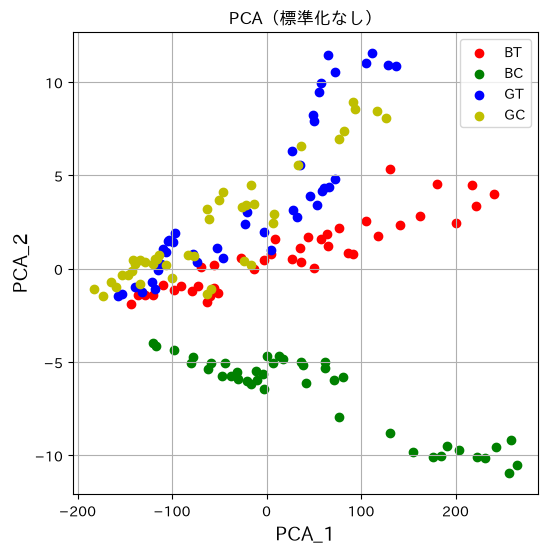

In [10]:
# PCAのプロット（標準化なし）
plt.figure(figsize=(6, 6))

colors = ['r', 'g', 'b','y']
species = ['BT', 'BC', 'GT','GC']

for color, specie in zip(colors, species):
    plt.scatter(X_pca[y == specie, 0], X_pca[y == specie, 1], 
                label=specie, 
                color=color
               )

plt.xlabel('PCA_1', fontsize =14)
plt.ylabel('PCA_2', fontsize =14)

plt.legend()
plt.grid()
plt.title('PCA（標準化なし）')
plt.show()

In [11]:
# 標準化なしの場合、PC1だけでどれだけの分散を説明しているか、
# また、どの元素がPC1を支配しているかを確認してみましょう
print('寄与率（標準化なし）:', np.round(pca.explained_variance_ratio_, 3))
print()
print('PC1の各元素の重み（絶対値が大きいほど影響大）:')
print(pd.Series(pca.components_[0], index=X.columns).sort_values())

寄与率（標準化なし）: [0.997 0.002]

PC1の各元素の重み（絶対値が大きいほど影響大）:
Cu    0.000105
Fe    0.000231
Zn    0.000738
Ca    0.005871
Na    0.009524
Mn    0.019012
Al    0.029193
Mg    0.068693
K     0.996966
dtype: float64


結果を見ると、**PC1だけでほぼ100%の分散を説明**しており、しかもPC1の重みはほぼ`K`（カリウム）だけで決まっていることが分かります。  

これは「PCAが本当に9元素すべての情報をバランスよく統合した」のではなく、**単に一番数値の大きい`K`（濃度が他の元素より2桁近く大きい）にPCAが引きずられているだけ**であることを意味します。  

次に、標準化してから同じことをやり直してみましょう。

### ③　標準化
PCAは、データのスケールに敏感であるため、次元削減の前に標準化が必要です。標準化では、各特徴量を平均0、標準偏差1にスケーリングし、異なるスケールを持つ特徴量が等しく扱われるようにします。これにより、PCAが特徴量のスケールに依存せず、データ全体の構造を正確に反映できます。

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
# データの標準化
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

In [14]:
# 主成分分析（PCA）：後の寄与率の確認のため、9つの主成分すべてを計算する
pca = PCA(n_components=9)  
X_pca = pca.fit_transform(X_std)

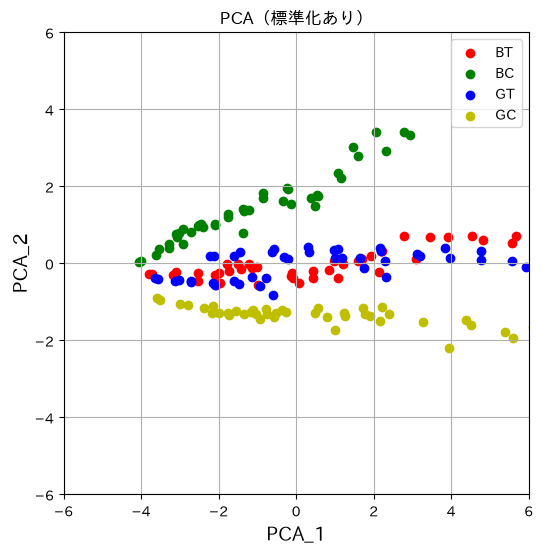

In [15]:
# PCAのプロット（標準化あり、PC1・PC2のみ表示）
plt.figure(figsize=(6, 6))

colors = ['r', 'g', 'b','y']
species = ['BT', 'BC', 'GT','GC']

for color, specie in zip(colors, species):
    plt.scatter(X_pca[y == specie, 0], X_pca[y == specie, 1], 
                label=specie, 
                color=color
               )

plt.xlabel('PCA_1', fontsize =14)
plt.ylabel('PCA_2', fontsize =14)
plt.xlim(-6,6)
plt.ylim(-6, 6)

plt.legend()
plt.grid()
plt.title('PCA（標準化あり）')
plt.show()

### 標準化の効果を数値で確認する
標準化した場合の寄与率を見てみましょう。標準化前は「PC1だけでほぼ100%」でしたが、標準化後はどう変わるでしょうか。

In [16]:
# 標準化なしの場合、PC1だけでどれだけの分散を説明しているか、
# また、どの元素がPC1を支配しているかを確認してみましょう
print('寄与率（標準化なし）:', np.round(pca.explained_variance_ratio_, 3))
print('PC1が説明する分散の割合:', round(pca.explained_variance_ratio_[0]*100, 1), '%（標準化前は99.7%でした）')
print()
print('PC1の各元素の重み（絶対値が大きいほど影響大）:')
print(pd.Series(pca.components_[0], index=X.columns).sort_values())

寄与率（標準化なし）: [0.717 0.14  0.077 0.029 0.021 0.007 0.006 0.002 0.002]
PC1が説明する分散の割合: 71.7 %（標準化前は99.7%でした）

PC1の各元素の重み（絶対値が大きいほど影響大）:
Cu    0.261085
K     0.301115
Mg    0.312425
Fe    0.339395
Ca    0.343823
Al    0.347737
Na    0.349047
Zn    0.364655
Mn    0.366639
dtype: float64


標準化後は、PC1が説明する分散の割合が大きく下がり、PC2以降も意味のある情報を持つようになったことが分かります。標準化前のPCAは実質的に「Kの量だけを見ている」に等しく、品種間の分離もはっきりしませんが、標準化後のグラフでは4品種がある程度分かれて分布している様子が見えるはずです。  

**PCAを使うときは、原則として標準化してから行うべき**であることが、この比較から実感できます。

### ④　寄与率と累積寄与率
PCAでは、データセットの特徴量を直交する新たな軸（主成分）に変換しますが、それぞれの主成分は、元のデータの分散（情報量）をどの程度説明できるかを示す寄与率を持ちます。  

例えば、寄与率が0.4であれば、その主成分だけで元のデータの40%の分散を説明できることを意味します。  

累積寄与率は、最初のn個の主成分まででどれだけの分散を説明できるかを示します。累積寄与率が1に近づくほど、それまでの主成分がほぼ全ての分散を説明していることを意味します。

pythonでは`explained_variance_ratio_`からは各主成分の寄与率を計算できます。`np.cumsum()`メソッドより累積寄与率を計算します。

In [17]:
# 寄与率の計算
explained_variance_ratio = pca.explained_variance_ratio_

# 累積寄与率の計算
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

In [18]:
explained_variance_ratio

array([0.71650408, 0.13997561, 0.07671744, 0.02861021, 0.02109378,
       0.00737171, 0.00557342, 0.00230621, 0.00184754])

In [19]:
cumulative_explained_variance

array([0.71650408, 0.85647969, 0.93319713, 0.96180734, 0.98290112,
       0.99027283, 0.99584625, 0.99815246, 1.        ])

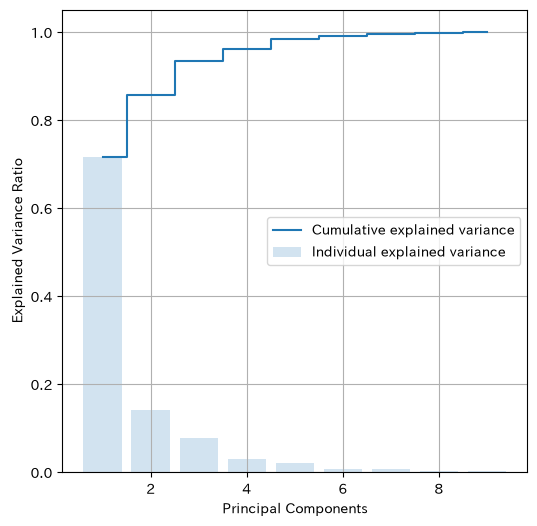

In [20]:
# 寄与率のプロット
plt.figure(figsize=(6, 6))

plt.bar(range(1, 10), explained_variance_ratio, alpha=0.2, align='center',
        label='Individual explained variance')

plt.step(range(1, 10), cumulative_explained_variance, where='mid',
         label='Cumulative explained variance')

plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')

plt.legend()
plt.grid()
plt.show()

## 2. t-分布型確率的近傍埋め込み（t-SNE）
t-分布型確率的近傍埋め込み（t-SNE）は、高次元データを低次元空間に効果的に埋め込む手法です。この手法は、データポイント間の局所的な類似性を保持しながら、データの高次元構造を視覚化します。

In [21]:
from sklearn.manifold import TSNE

### ①　モデル構築
t-SNEクラスは、Scikit-learnライブラリから提供されるt-分布型確率的近傍埋め込みのクラスです。このクラスを使用して、高次元データを低次元空間に埋め込み、データの局所的な構造を保持しながら視覚化します。t-SNEは、データポイント間の類似性を反映する2次元または3次元のプロットを生成し、複雑なデータのパターンを理解するのに役立ちます。

PCAの節で確認した通り、標準化をしないと特定の元素（今回はK）にPCAが引きずられてしまう問題がありました。t-SNEも距離をベースにした手法のため、同じ理由で標準化されたデータを使う必要があります。ここでは最初から標準化済みのデータ`X_std`を使います。

In [22]:
# t-SNEの実行（標準化済みデータ）
tsne = TSNE(n_components=2, random_state=42)
X_tsne_std = tsne.fit_transform(X_std)

### 【解説】t-SNEの主なハイパーパラメータ

| パラメータ | 説明 | デフォルト値 |
| --- | --- | --- |
| `n_components` | 埋め込み後の次元数。通常2または3。 | 2 |
| `perplexity` | 近傍とみなす点の数の目安。小さいと局所的構造、大きいと大域的構造を重視。データ数に応じて5〜50程度で調整。 | 30 |
| `learning_rate` | 埋め込み空間での更新のステップサイズ。小さすぎると収束が遅く、大きすぎると発散する可能性がある。 | 200（自動調整の場合あり） |
| `n_iter` | 最適化の反復回数。通常1000回以上が推奨される。 | 1000 |
| `init` | 埋め込みの初期化方法。`'random'`または`'pca'`。 | `'pca'`（新しいバージョンでは`'pca'`が既定になっています） |
| `metric` | データ間の距離指標。ユークリッド距離（`'euclidean'`）など。 | `'euclidean'` |
| `random_state` | 再現性のための乱数シード。 | `None` |

特に`perplexity`と`learning_rate`は結果の見た目に大きく影響するため、いくつかの値を試して比較することが推奨されます（演習問題で扱います）。

### ②　二次元プロット（可視化）

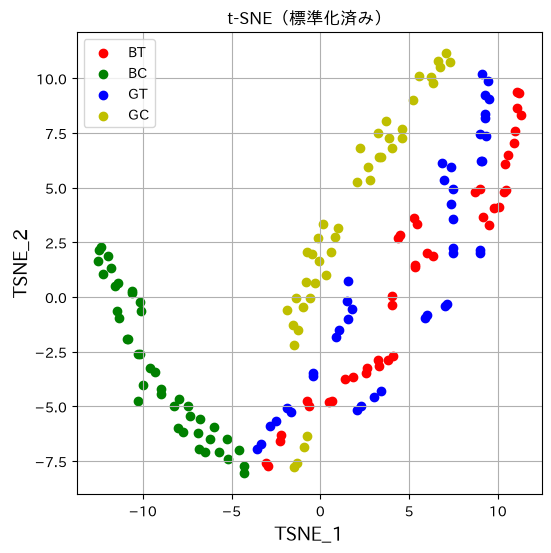

In [23]:
# t-SNEのプロット（標準化済みデータ）
plt.figure(figsize=(6, 6))

colors = ['r', 'g', 'b','y']
species = ['BT', 'BC', 'GT','GC']

for color, specie in zip(colors, species):
    plt.scatter(X_tsne_std[y == specie, 0], X_tsne_std[y == specie, 1], 
                label=specie, 
                color=color
               )

plt.xlabel('TSNE_1', fontsize =14)
plt.ylabel('TSNE_2', fontsize =14)

plt.legend()
plt.grid()
plt.title('t-SNE（標準化済み）')
plt.show()

図を見ると、品種ごとにある程度まとまりが見える一方で、4品種がくっきりと分かれているわけではないことが分かります。t-SNEも距離をベースにした手法のため、PCAのときと同様に、データの中で最も分散が大きい方向（抽出濃度・抽出時間による違い）の影響を受けています。この背景にある理由は、この後のクラスタリングの節で詳しく調べていきます。

## 3. 統一マニホールド近似と射影（UMAP）
統一マニホールド近似と射影（UMAP）は、高次元データを低次元空間に効率的に埋め込む手法です。UMAPは、データの局所的な構造と全体的な構造を保持しながら、複雑なデータの可視化を行います。

In [24]:
from umap import UMAP

### ①　モデル構築
UMAPクラスは、umap-learnライブラリから提供される統一マニホールド近似と射影の実装クラスです。このクラスを使用して、高次元データを低次元空間に効果的に埋め込むことができます。t-SNEと同様の理由で、標準化済みのデータ`X_std`を使います。

In [25]:
# UMAPの実行（標準化済みデータ）
umap_model = UMAP(n_components=2, random_state=42)
X_umap_std = umap_model.fit_transform(X_std)

### ②　二次元プロット（可視化）

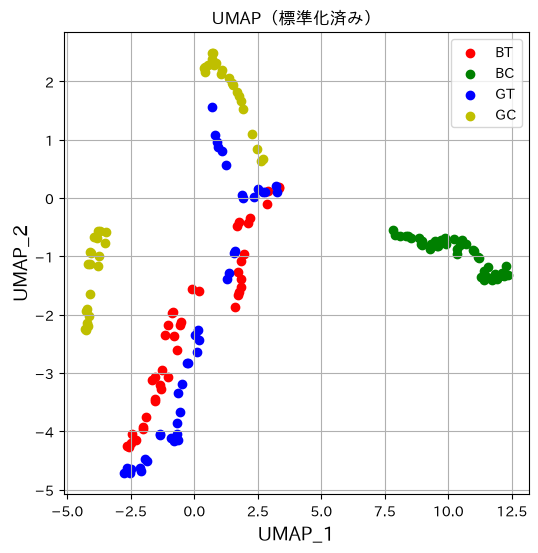

In [26]:
# UMAPのプロット（標準化済みデータ）
plt.figure(figsize=(6, 6))

colors = ['r', 'g', 'b','y']
species = ['BT', 'BC', 'GT','GC']

for color, specie in zip(colors, species):
    plt.scatter(X_umap_std[y == specie, 0], X_umap_std[y == specie, 1], 
                label=specie, 
                color=color
               )

plt.xlabel('UMAP_1', fontsize =14)
plt.ylabel('UMAP_2', fontsize =14)

plt.legend()
plt.grid()
plt.title('UMAP（標準化済み）')
plt.show()

### 【解説】UMAPの主なハイパーパラメータ

| パラメータ | 説明 | デフォルト値 |
| --- | --- | --- |
| `n_neighbors` | 近傍点の数。小さいと局所構造、大きいと大域構造を強調。5〜50程度が目安。 | 15 |
| `min_dist` | 埋め込み空間での点同士の最小距離。小さいと密集、大きいと疎になる。 | 0.1 |
| `n_components` | 埋め込み後の次元数。 | 2 |
| `metric` | 距離指標（`'euclidean'`など）。 | `'euclidean'` |
| `random_state` | 再現性のための乱数シード。 | `None` |

`n_neighbors`と`min_dist`は結果への影響が特に大きいパラメータです。

### ③　ハイパーパラメータが可視化結果に与える影響を確認する

まず`n_neighbors`（近傍点の数）を変えてみます。値が小さいほど局所的な構造を、大きいほど大域的な構造を重視します。

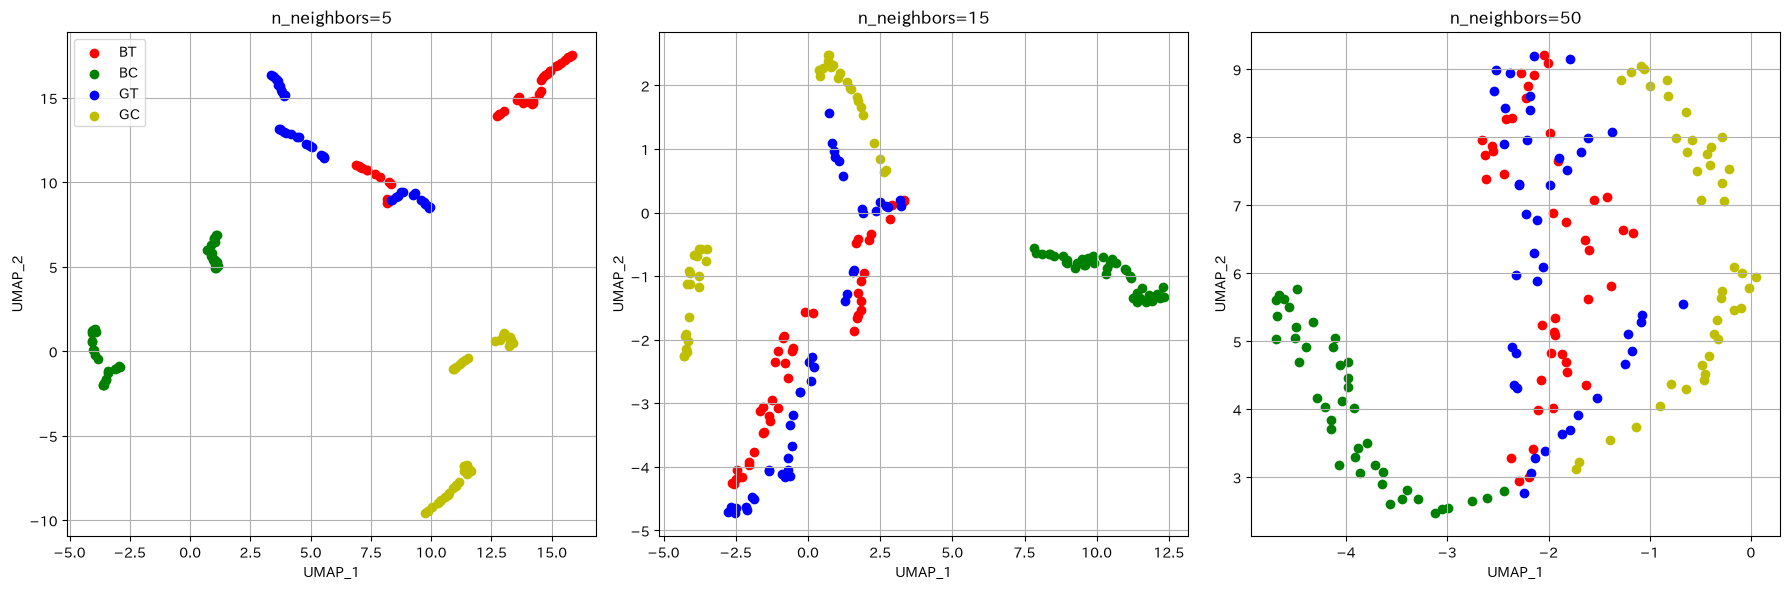

In [27]:
# n_neighborsを変えて比較（min_distは既定値0.1のまま）
fig, axes = plt.subplots(1, 3, figsize=(18,6))

for ax, n in zip(axes, [5, 15, 50]):
    um = UMAP(n_components=2, n_neighbors=n, random_state=42)
    X_tmp = um.fit_transform(X_std)
    for color, specie in zip(colors, species):
        ax.scatter(X_tmp[y == specie, 0], X_tmp[y == specie, 1], label=specie, color=color)
    ax.set_title(f'n_neighbors={n}')
    ax.set_xlabel('UMAP_1')
    ax.set_ylabel('UMAP_2')
    ax.grid()

axes[0].legend()
plt.tight_layout()
plt.show()

`n_neighbors`が小さい（5）ほど、点があちこちに細かく分裂しやすくなり、大きい（50）ほど、全体がまとまった1つの塊に近づいていく様子が確認できるはずです。

次に`min_dist`（埋め込み空間での点同士の最小距離）を変えてみます。値が小さいほど点同士が密集し、大きいほど点間が広がって疎になります。

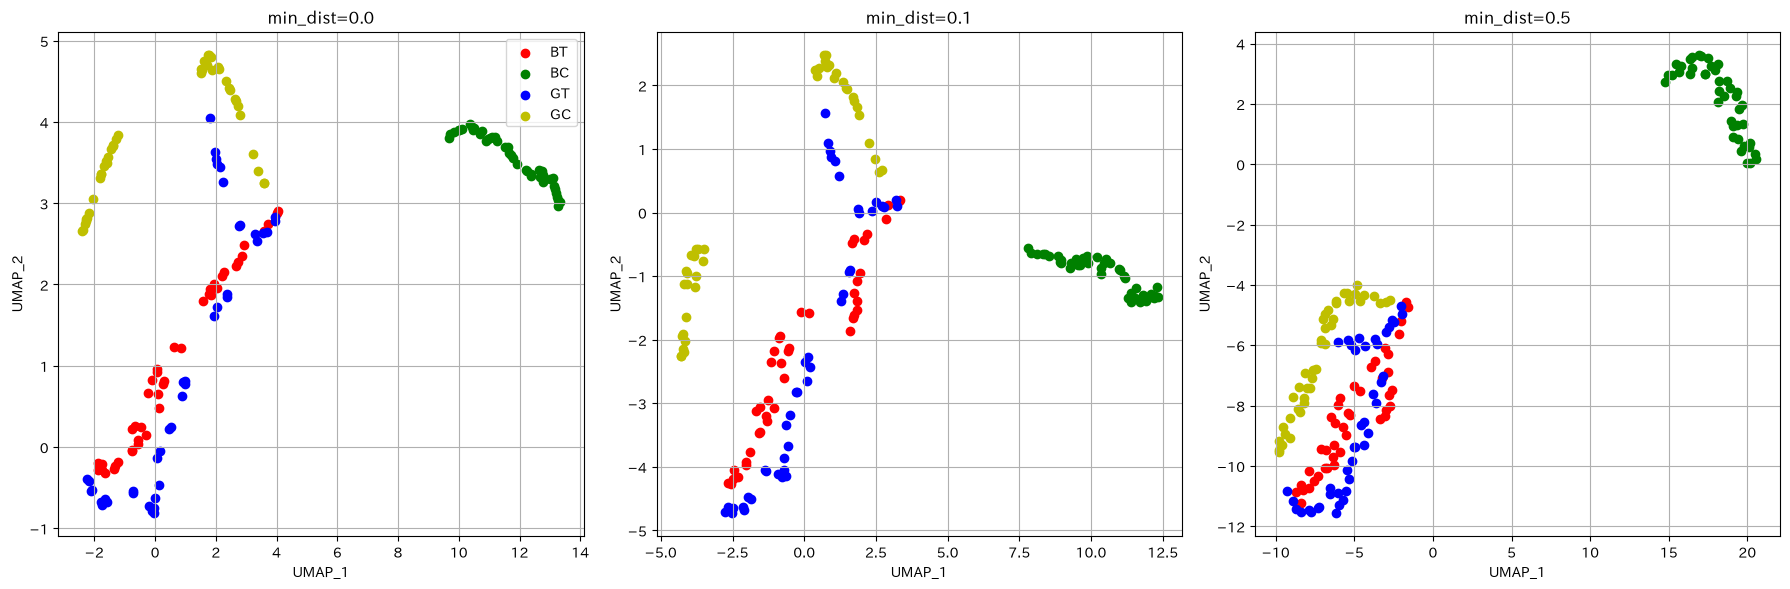

In [28]:
# min_distを変えて比較（n_neighborsは既定値15のまま）
fig, axes = plt.subplots(1, 3, figsize=(18,6))

for ax, d in zip(axes, [0.0, 0.1, 0.5]):
    um = UMAP(n_components=2, min_dist=d, random_state=42)
    X_tmp = um.fit_transform(X_std)
    for color, specie in zip(colors, species):
        ax.scatter(X_tmp[y == specie, 0], X_tmp[y == specie, 1], label=specie, color=color)
    ax.set_title(f'min_dist={d}')
    ax.set_xlabel('UMAP_1')
    ax.set_ylabel('UMAP_2')
    ax.grid()

axes[0].legend()
plt.tight_layout()
plt.show()

`min_dist`が小さいほど、同じような点同士がぎゅっと密集した小さな塊になり、大きいほど点同士が広がって全体的にぼんやりとした印象になることが確認できるはずです。

**注意：** UMAPの2次元プロット上での「塊の大きさ」や「塊同士の距離」は、`n_neighbors`・`min_dist`の設定によって大きく変わります。これらの図だけを見て「この2つの品種は近い／遠い」と定量的に結論づけることはできません。UMAPはあくまで可視化のための次元削減であり、距離や密度をそのまま定量的な指標として使うことには注意が必要です。

以降の分析では、既定値に近い`n_neighbors=15`・`min_dist=0.1`（＝`UMAP(n_components=2, random_state=42)`の既定設定）で計算した`X_umap_std`を使用します。

---

# 3. まとめと演習問題

## まとめ

本ノートブックでは、次のことを学びました。

* 欠損値（抽出条件が記録されていない79件）を`dropna()`で除去する前処理
* PCAは標準化しないと1つの元素（K）だけで結果がほぼ決まってしまうことを、寄与率と係数の実際の数値で確認しました
* t-SNE・UMAPも距離をベースにした手法のため、同じ理由で標準化したデータを使う必要があること
* 寄与率・累積寄与率によるPCAの情報保持量の確認
* UMAPの主要ハイパーパラメータ（`n_neighbors`・`min_dist`）が2次元への可視化結果に与える影響、およびUMAPの距離・密度を定量的な指標として使うべきではないという注意点

## 本ノートブックでは扱っていないこと（今後の課題）

1. **クラスタリング（階層クラスタリング・k-means）は扱っていません。** 後編`Scikit-learn-7_Clustering.ipynb`で扱います。
2. **なぜPCAで品種がはっきり分離しないのか（抽出濃度・抽出時間の影響）は扱っていません。** 後編で詳しく検証します。
3. **t-SNEの`perplexity`・`learning_rate`を変えた比較は行っていません。**

## 演習問題

1. t-SNEの`perplexity`を5・30・50と変えて、プロットの見た目がどう変わるか比較してみましょう。
2. UMAPの`n_neighbors`・`min_dist`について、本編で試した値以外の組み合わせ（例：`n_neighbors=100`、`min_dist=0.9`）でも試してみましょう。
3. PCAの寄与率のグラフ（累積寄与率）を見て、分散の90%を説明するには何個の主成分が必要か確認してみましょう。